In [64]:
import wikipedia 
import uuid
                                                                                                                                                                                                                                                                                      
wikipedia.set_user_agent(f"MyAgenticApp/1.0 ({str(uuid.uuid4())}@example.com)")

import requests
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langchain_community.tools import WikipediaQueryRun, ArxivQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

load_dotenv()

groq_key = os.environ["GROQ_API_KEY"]
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
W_API_KEY = os.getenv('WEATHER_API_KEY')

llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=groq_key)

In [65]:
api_wrapper_arx = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arx)
print(arxiv.name)

arxiv


In [66]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [67]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [68]:
wiki.invoke("What is agentic ai")

'Page: AI agent\nSummary: An AI agent, also known as agentic AI in buzzword form, is an artificial intelligence program that can pursue goals, use software or other tools, and take actions with some level of autonomy. Agentic AI contrasts with tool-like AI use for narrow, specific tasks such as answering questions - as with chatbots in the non-agentic forms that were common in 2023, or with traditional machine learning algorithms.\nWhile there is no universally agreed-upon definition of an AI agent'

In [69]:
tav = TavilySearch()

In [70]:
tav.invoke("Give me the current sports news")

{'query': 'Give me the current sports news',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Breaking & Latest Sports News',
   'url': 'https://www.reuters.com/sports',
   'content': "Marking the end of an eventful career, Chicago Fire FC winger Chris Mueller announced his retirement from professional soccer on Friday.\n\nMLS: Chicago Fire FC at CF Montreal\n\nCharlie Woods put himself in contention at the Junior Players Championship on Friday, firing a 1-under-par 71 at TPC Sawgrass in Ponte Vedra \u200bBeach, Fla.\n\nPGA: PNC Championship [...] # Sports\n\nDefending champion Carlos Alcaraz continued to fly \u200bhigh at the U.S. Open while Aryna Sabalenka overcame a distraction from the smell of cannabis in the Flushing Meadows complex to reach \u200cthe fourth round on Friday.\n\nU.S. Open\nReuters Inside Track newsletter\n\n## Reuters Inside Track\n\nInside Track is your guide to the biggest global sports news, on and off the pitch. [...] Premi

In [157]:
# defining `get_weather` tool

def get_weather(city:str):
    # doc strings play an important role, it make the tool understable to the LLM
    # The LLM now knows that by using this tool, it can get real time info of any city's weather
    """Get the current weather details of a city"""

    url = f"https://api.openweathermap.org/geo/1.0/direct?q={city}&appid={W_API_KEY}"

    geo_details = requests.get(url)

    lat = geo_details.json()[0]['lat']
    lon = geo_details.json()[0]['lon']

    w_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={W_API_KEY}&units=metric"

    response = requests.get(w_url)
    return response.json()

def search_arxiv(paper:str):
    """Get the credible information of any research paper on arxiv using paper name or id"""
    response = arxiv.invoke(paper)

    return response

In [158]:
llm_with_tool = llm.bind_tools([get_weather, wiki, search_arxiv, tav])
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B5911180D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B5B928CA90>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_weather', 'description': 'Get the current weather details of a city', 'parameters': {'

In [73]:
res = llm_with_tool.invoke("what is the weather in London?")

In [74]:
print(res.tool_calls)
print(res.additional_kwargs['reasoning_content'])

print(res.content, "\n# the response is empty")

[{'name': 'get_weather', 'args': {'city': 'London'}, 'id': 'fc_99790416-bae1-46e1-a5a0-870d1713a94e', 'type': 'tool_call'}]
We need to call get_weather with city "London".
 
# the response is empty


In [75]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [154]:
def llm_tools(state:State):
    return {"messages": [llm_with_tool.invoke(state['messages'])]}

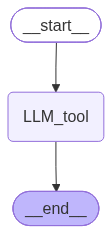

In [77]:
from IPython.display import display, Image
from langgraph.graph import START, END, StateGraph

graph_build = StateGraph(State)

graph_build.add_node("LLM_tool", llm_tools)

graph_build.add_edge(START, "LLM_tool")
graph_build.add_edge("LLM_tool", END)

graph = graph_build.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [78]:
res = graph.invoke({"messages": "What is the weather in paris right now?"})
res

{'messages': [HumanMessage(content='What is the weather in paris right now?', additional_kwargs={}, response_metadata={}, id='1ebcb425-616c-4755-98f1-5eb876218464'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks for current weather in Paris. We need to call the get_weather function.', 'tool_calls': [{'id': 'fc_461568be-b638-4c1e-a071-19169b48d72b', 'function': {'arguments': '{"city":"Paris"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 131, 'total_tokens': 173, 'completion_time': 0.052469451, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.006437897, 'prompt_tokens_details': None, 'queue_time': 0.330459002, 'total_time': 0.058907348}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_99996fee8e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a071a4-fd69-71a3-af58-85e

In [79]:
res['messages'][-1].tool_calls

[{'name': 'get_weather',
  'args': {'city': 'Paris'},
  'id': 'fc_461568be-b638-4c1e-a071-19169b48d72b',
  'type': 'tool_call'}]

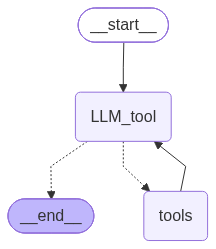

In [159]:
from langgraph.prebuilt import ToolNode, tools_condition

graph_build = StateGraph(State)

graph_build.add_node("LLM_tool", llm_tools)
graph_build.add_node("tools", ToolNode([get_weather, tav, search_arxiv, wiki]))

graph_build.add_edge(START, "LLM_tool")
# connecting the `get_weather` tool to it
graph_build.add_conditional_edges("LLM_tool", tools_condition)
graph_build.add_edge("tools", "LLM_tool")

graph = graph_build.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
res = graph.invoke({"messages": "What is the weather in Kolkata right now?"})
print(res['messages'][-1].content)

# with the help of weather tool, it can access real time weather now.

**Kolkata – Current Weather (as of now)**  
- **Temperature:** 29 °C (≈ 84 °F)  
- **Feels Like:** 36 °C (≈ 97 °F)  
- **Conditions:** Overcast clouds (≈ 93 % cloud cover)  
- **Humidity:** 94 %  
- **Wind:** 4.1 m/s (~ 15 km/h) from the south‑southwest (200°)  
- **Pressure:** 1006 hPa  
- **Visibility:** 10 km  

It’s a hot, humid day with heavy cloud cover and light wind. Stay hydrated and consider an umbrella just in case!


In [105]:
res = graph.invoke({"messages": "tell me today's news related to Indian politics, give me top 5"})

In [106]:
print(res['messages'][-1].content)

**Top 5 Indian‑politics stories (today’s date: 5 August 2026)**  

| # | Headline & source | Key takeaway |
|---|-------------------|--------------|
| 1 | **“Cockroach Janta Party’s founder says Indian government took website down”** – *Al Jazeera* (23 May 2026) | The satirical “Cockroach Janta Party” (CJP), launched by student‑activist Abhijeet Dipke, has amassed a million‑plus sign‑ups. Dipke says the government seized the CJP website after the party demanded Education Minister Dharmendra Pradhan’s resignation over leaked exam papers. | <https://www.aljazeera.com/news/2026/5/23/cockroach-janta-partys-founder-says-indian-government-took-website-down> |
| 2 | **“India swats cockroach movement over ‘national security’”** – *DW* (22 May 2026) | Delhi’s authorities blocked the CJP’s X account and threatened to shut down its Instagram page, citing “national‑security” concerns. The move follows widespread protests demanding accountability for exam‑paper leaks. | <https://www.dw.com/en/india

In [135]:
res = graph.invoke({"messages": "Use the Wikipedia tool to look up Kirkwood gaps. Tell me the value of the orbital period mentioned in the article for the 3:1 resonance, using only the retrieved article."})

In [ ]:
print(res['messages'][-1])

{'reasoning_content': 'The Wikipedia tool returned a summary but not the full article. The user asks: "Use the Wikipedia tool to look up Kirkwood gaps. Tell me the value of the orbital period mentioned in the article for the 3:1 resonance, using only the retrieved article." We need to retrieve the article via Wikipedia tool. The summary shows that the 3:1 resonance period is 3.95 years. But the user says "using only the retrieved article." The tool gave summary, not full article. But we can use the summary. The period value is 3.95 years. Provide that.'}


In [160]:
res = graph.invoke({"messages": "call the axriv tool, and tell me about attention is all you need research paper, don't answer with your knowledge, Call the tool!"})

In [164]:
print(res['messages'][-1])

content='**Search Result from arXiv**\n\n- **Published:** 2023-08-02  \n- **Title:** *Attention Is All You Need*  \n- **Authors:** Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin  \n- **Summary:**  \n  The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder‑decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, which relies entirely on attention mechanisms and eliminates recurrence and convolutions entirely. This architecture achieves state‑of‑the‑art results on several machine translation benchmarks while significantly reducing training time.' additional_kwargs={'reasoning_content': 'The user asked: "call the axriv tool, and tell me about attention is all you need research paper, don\'t answer with your knowledge, Call the to